---
title: "PageRank"
categories: []
---

The [World Wide Web](https://en.wikipedia.org/wiki/PageRank) is a directed graph: pages are nodes and hyperlinks are edges, pointing from the page that contains them to the page they reference. Ranking pages by importance is the problem that founded the search industry, and its solution rests on one recursive idea: **a page is important if important pages link to it**. The definition is circular, which is precisely what makes it a fixed-point problem: the kind this course has a tool for.

Chapter 9 ended with the power method, the iterative engine that finds a matrix's dominant eigenvector using nothing but matrix-vector products, and noted in passing that it is the algorithm behind PageRank. This chapter makes good on that claim. The link structure becomes a matrix, importance becomes an eigenvector, and the power method becomes the ranking algorithm. Two ingredients appear that Chapter 9's symmetric demo did not exercise: the matrix is *nonsymmetric* and *column-stochastic*: the transition matrix of a [Markov chain](https://en.wikipedia.org/wiki/Markov_chain).

The view that makes the connection work is the [random surfer]{.mark}: a hypothetical reader who starts on a random page, follows a random link on each page, and repeats forever. The fraction of time the surfer spends on each page is a natural measure of importance, and the graph alone determines it — again a fixed point, this time of a probabilistic system.


## A teaching web

The ideas are developed on a small synthetic web of sixteen pages, labeled $\mathrm{A}$ through $\mathrm{P}$, engineered to contain the three structures that break naive ranking: two **hubs** (pages with many out-links), a [dangling node]{.mark} (a page with no out-links at all), and a *sink cluster* (a group of pages that link only to one another). The link structure is deliberately asymmetric: page $\mathrm{A}$ receives eleven in-links while page $\mathrm{P}$ receives none, so a sensible ranking is not obvious from link counts alone.

The adjacency matrix $\mathbf{A} \in \mathbb{R}^{n \times n}$ records the links: $A_{ds} = 1$ when page $s$ links to page $d$, and $0$ otherwise. Column $s$ lists the out-links of page $s$; row $d$ lists the in-links of page $d$.

| Page | Out-links | Page | Out-links |
|------|-----------|------|-----------|
| A | B C D E F G H | I | J K |
| B | A C D | J | I K |
| C | A B | K | I J |
| D | A B | L | A B C |
| E | A | M | A L |
| F | A B | N | A M |
| G | A B | O | A N |
| H | none | P | A O |

Column $\mathrm{H}$ is empty: the dangling node. And because $\mathrm{I}, \mathrm{J}, \mathrm{K}$ link only to one another, no surfer mass that enters that cluster can ever leave it, a fact that will matter shortly.


In [1]:
from watchtower.core import set_format
set_format("svg")


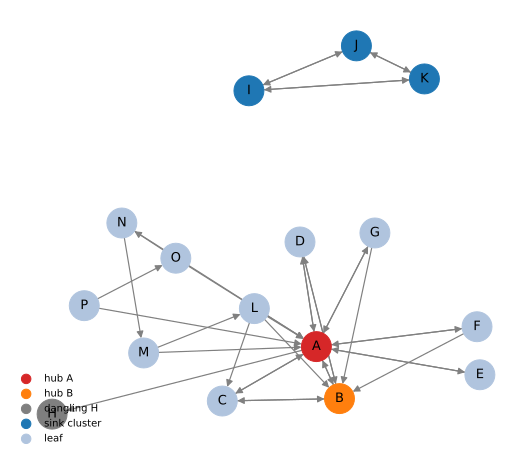

[[0 1 1 1 1 1 1 0 0 0 0 1 1 1 1 1]
 [1 0 1 1 0 1 1 0 0 0 0 1 0 0 0 0]
 [1 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]


In [2]:
#| label: fig-pagerank-graph
#| cap: "**Teaching web.** Sixteen pages with two hubs (A, B), a dangling node (H), and a closed sink cluster (I, J, K). Arrows point from the linking page to the linked page."
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

pages = list('ABCDEFGHIJKLMNOP')
out = {'A': 'BCDEFGH', 'B': 'ACD', 'C': 'AB', 'D': 'AB', 'E': 'A',
       'F': 'AB', 'G': 'AB', 'H': '', 'I': 'JK', 'J': 'IK', 'K': 'IJ',
       'L': 'ABC', 'M': 'AL', 'N': 'AM', 'O': 'AN', 'P': 'AO'}

n = len(pages)
index = {p: i for i, p in enumerate(pages)}
A = np.zeros((n, n))
for s, dests in out.items():
    for d in dests:
        A[index[d], index[s]] = 1.0          # <1>

G = nx.DiGraph()
G.add_nodes_from(pages)
G.add_edges_from((s, d) for s, dests in out.items() for d in dests)

colors = {'A': 'tab:red', 'B': 'tab:orange', 'H': 'tab:gray',
          'I': 'tab:blue', 'J': 'tab:blue', 'K': 'tab:blue'}
node_color = [colors.get(p, 'lightsteelblue') for p in pages]
pos = nx.spring_layout(G, seed=0, k=1.2, iterations=60)

fig, ax = plt.subplots(figsize=(7.5, 6.5))
nx.draw_networkx(G, pos, ax=ax, node_color=node_color, node_size=900,
                 font_size=13, arrowsize=14, edge_color='gray', width=1.2)
for label, c in [('hub A', 'tab:red'), ('hub B', 'tab:orange'),
                 ('dangling H', 'tab:gray'), ('sink cluster', 'tab:blue'),
                 ('leaf', 'lightsteelblue')]:
    ax.scatter([], [], c=c, s=90, label=label)   # <2>
ax.legend(loc='lower left', frameon=False)
ax.axis('off')
fig.tight_layout()
plt.show()

print(A.astype(int))


**The teaching graph.**

- `<1>` The adjacency convention: a $1$ in row $d$, column $s$ says page $s$ links to page $d$, so column $s$ is the out-link list of page $s$.
- `<2>` Empty scatter points supply the legend: hubs in red and orange, the dangling node in gray, the sink cluster in blue, leaves in light blue.

The printed matrix makes the structure legible. Column $\mathrm{H}$ is entirely zero: the dangling node. The submatrix on rows and columns $\mathrm{I}, \mathrm{J}, \mathrm{K}$ is the closed cluster: its columns have their $1$s inside the cluster and nowhere else, so mass that enters it never leaves. Page $\mathrm{A}$'s row holds eleven $1$s, the most in-links of any page; page $\mathrm{P}$'s row is empty. A naive "count the in-links" ranking would put $\mathrm{A}$ first and $\mathrm{P}$ last, which is the right spirit, but the closed cluster will defeat the naive *linear* ranking below.


## From links to probabilities

A surfer at page $s$ picks uniformly among its out-links. Normalizing column $s$ of $\mathbf{A}$ by the out-degree $\operatorname{out}(s) = \sum_d A_{ds}$ turns each column into a probability distribution over the next page:

$$\mathbf{P}_{ds} = \frac{A_{ds}}{\operatorname{out}(s)}, \qquad \sum_d \mathbf{P}_{ds} = 1.$$

The matrix $\mathbf{P}$ is [column-stochastic]{.mark}: nonnegative entries with every column summing to one. It is the transition matrix of a [Markov chain](https://en.wikipedia.org/wiki/Markov_chain) on the pages: $\mathbf{P}_{ds}$ is the probability that a surfer at page $s$ moves to page $d$. Unlike every matrix iterated in Chapter 9, $\mathbf{P}$ is not symmetric: the web's links point one way, so the full nonsymmetric machinery of that chapter applies.

The cell below builds $\mathbf{P}$ and records its spectrum. The dangling column $\mathrm{H}$ is left as a zero column for now; the division by $\operatorname{out}(\mathrm{H}) = 0$ is undefined, and confronting that undefinedness is the point.


In [3]:
import numpy as np

outdeg = A.sum(axis=0)                       # <1>
with np.errstate(divide='ignore', invalid='ignore'):
    P = A / outdeg
P = np.nan_to_num(P, nan=0.0)                # <2>

print('out-degrees :', dict(zip(pages, outdeg.astype(int).tolist())))
print('column sums :', np.round(P.sum(axis=0), 3))
print()
print('P =')
print(np.round(P, 2))

lam = np.linalg.eigvals(P)
lam_abs = np.sort(np.abs(lam))[::-1]
print()
print('|lambda_1|         =', np.round(lam_abs[0], 6))
print('|lambda_2/lambda_1| =', np.round(lam_abs[1] / lam_abs[0], 6))


out-degrees : {'A': 7, 'B': 3, 'C': 2, 'D': 2, 'E': 1, 'F': 2, 'G': 2, 'H': 0, 'I': 2, 'J': 2, 'K': 2, 'L': 3, 'M': 2, 'N': 2, 'O': 2, 'P': 2}
column sums : [1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1.]

P =
[[0.   0.33 0.5  0.5  1.   0.5  0.5  0.   0.   0.   0.   0.33 0.5  0.5
  0.5  0.5 ]
 [0.14 0.   0.5  0.5  0.   0.5  0.5  0.   0.   0.   0.   0.33 0.   0.
  0.   0.  ]
 [0.14 0.33 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.33 0.   0.
  0.   0.  ]
 [0.14 0.33 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.  ]
 [0.14 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.  ]
 [0.14 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.  ]
 [0.14 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.  ]
 [0.14 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.5  0.5  0.   0.   0.
  0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0. 

**The stochastic matrix.**

- `<1>` The out-degree of page $s$ is the sum of column $s$ of $\mathbf{A}$.
- `<2>` The dangling column $\mathrm{H}$ produced a $0/0$; it is set to zero rather than left as `nan`.

Every nonzero column of $\mathbf{P}$ sums to one, as the printed column sums show; the exception is column $\mathrm{H}$, whose out-degree is zero. The spectrum confirms the theory: $\lambda_1 = 1$ exactly, and $|\lambda_2/\lambda_1| = 0.952$. By the convergence-rate formula of Chapter 9 the power method will need hundreds of iterations here, a first hint that the undamped matrix is not through misbehaving.

Column-stochasticity is a statement about the *left* eigenvector: $\mathbf{1}^{\mathsf T}\mathbf{P} = \mathbf{1}^{\mathsf T}$. The ranking lives on the *right* side: a vector $\mathbf{x}$ with $\mathbf{P}\mathbf{x} = \mathbf{x}$, $\mathbf{x} \ge \mathbf{0}$ and $\sum_d x_d = 1$ is a [stationary distribution]{.mark}, the long-run fraction of visits the surfer pays to each page. For the symmetric matrices of Chapters 2 and 9 the two sides coincide; for a nonsymmetric $\mathbf{P}$ they are different objects, and the biorthogonality of Chapter 9 becomes operational.


## Power iteration, undamped

Chapter 9's power method finds the dominant eigenvector by iterating $\mathbf{x}_{k+1} = \mathbf{P}\mathbf{x}_k$ and renormalizing. Nothing in its derivation required symmetry, so it applies to the nonsymmetric $\mathbf{P}$ unchanged; only the normalization differs. Chapter 9 normalized to unit 2-norm to feed the Rayleigh quotient; here the limit is a probability distribution, so the iterates are normalized to sum to one. The two normalizations change the scale, not the direction, and the direction is what converges.

The convergence rate is the same formula as in Chapter 9: the error in direction decays like $|\lambda_2/\lambda_1|^k$, now $0.952^k$. The iteration below runs until consecutive iterates agree to $10^{-10}$ in the 2-norm.


In [4]:
def power_method(P, max_iter=5000, tol=1e-10):
    """Dominant right eigenvector of P: x_{k+1} = P x_k, normalized to sum one."""
    n = P.shape[0]
    x = np.full(n, 1.0 / n)
    residuals = []
    for k in range(max_iter):
        x_new = P @ x                        # <1>
        x_new = x_new / x_new.sum()          # <2>
        residuals.append(np.linalg.norm(x_new - x, 2))
        if residuals[-1] < tol:
            break
        x = x_new
    return x, np.array(residuals), k + 1

scores, residuals, iters = power_method(P)
rank = np.argsort(-scores)

print(f'converged in {iters} iterations, final residual {residuals[-1]:.1e}')
for i in rank:
    print(f'  {pages[i]}: {scores[i]:.6f}')


converged in 434 iterations, final residual 1.0e-10
  I: 0.333333
  J: 0.333333
  K: 0.333333
  A: 0.000000
  B: 0.000000
  C: 0.000000
  D: 0.000000
  E: 0.000000
  F: 0.000000
  G: 0.000000
  H: 0.000000
  L: 0.000000
  M: 0.000000
  N: 0.000000
  O: 0.000000
  P: 0.000000


**The undamped ranking.**

- `<1>` One matrix-vector product per step; this is the entire per-iteration cost of the method, as in Chapter 9.
- `<2>` Sum-to-one normalization keeps $\mathbf{x}$ a probability vector; only the direction matters for convergence.

The iteration converged and produced a ranking that is obviously wrong. All of the probability mass sits on the sink cluster $\{\mathrm{I}, \mathrm{J}, \mathrm{K}\}$, split evenly, and every other page — including $\mathrm{A}$, the most-linked page in the graph — scores zero to six decimals. The failure has two independent causes, each a violation of an assumption the eigenvector story silently makes.

| Failure | Mechanism |
|---------|-----------|
| Dangling node $\mathrm{H}$ | Column $\mathrm{H}$ of $\mathbf{P}$ is zero, so a surfer at $\mathrm{H}$ has no next page. Mass vanishes at $\mathrm{H}$ instead of circulating, and the matrix is not stochastic. |
| Closed sink cluster | $\{\mathrm{I}, \mathrm{J}, \mathrm{K}\}$ is a [reducible]{.mark} component: mass that enters can never leave, so the chain has multiple closed classes and the stationary distribution is not unique. The iteration returns the distribution the cluster's dominant eigenvalue forces. |

Both defects are repaired by a single mechanism: damping.


## Damping and the Google matrix

The two failures share a root cause: the surfer can get trapped, at $\mathrm{H}$ with nowhere to go, or inside a cluster with no way out. The [PageRank](https://en.wikipedia.org/wiki/PageRank) remedy makes getting trapped impossible, in two small edits to $\mathbf{P}$.

**Dangling repair.** A surfer at a page with no out-links picks a uniformly random page. Replace every zero column of $\mathbf{P}$ by the uniform column $\tfrac{1}{n}\mathbf{1}$; call the result $\widetilde{\mathbf{P}}$, which is now genuinely column-stochastic.

**Teleportation.** At every step the surfer follows a link with probability $\alpha$ and jumps to a uniformly random page with probability $1-\alpha$. The transition matrix of this modified walk is the [Google matrix]{.mark}

$$\boxed{\;\mathbf{G} = \alpha\widetilde{\mathbf{P}} + (1-\alpha)\,\tfrac{1}{n}\mathbf{1}\mathbf{1}^{\mathsf T},\;}$$

with [damping factor]{.mark} $\alpha \approx 0.85$. As a convex combination of stochastic matrices, $\mathbf{G}$ is stochastic; and because the teleport term is positive, every entry of $\mathbf{G}$ is at least $(1-\alpha)/n$: the matrix is positive.

Positivity is the entire point. The [Perron–Frobenius theorem](https://en.wikipedia.org/wiki/Perron%E2%80%93Frobenius_theorem) says a positive matrix has a unique dominant eigenvalue $\lambda_1 = 1$, strictly larger in modulus than every other eigenvalue, with a strictly positive eigenvector. In Markov-chain language the walk is now [irreducible]{.mark} and [aperiodic]{.mark}: every page can be reached from every page, and a page can return to itself in one step. The stationary distribution therefore exists, is unique, and is reached from any starting vector. That unique vector is **PageRank**.[^name]

Damping also buys a quantitative guarantee. Every eigenvalue of $\mathbf{G}$ other than $\lambda_1 = 1$ satisfies $|\lambda_i| \le \alpha$,[^bound] so the power method's rate on $\mathbf{G}$ is at most $0.85$ for *any* link structure — the pathological ratio $0.952$ is structurally impossible now. This is the same regularizing move as the ridge shift $\mathbf{A} + \lambda\mathbf{I}$ of Chapter 4, which stabilizes the least-squares problem of Chapter 8: a cheap rank-one term that pushes the spectrum into the regime where the iteration is well posed.

[^name]: The name puns on *rank* and on Larry Page, who with Sergey Brin described the method in 1998.
[^bound]: The bound $|\lambda_2(\mathbf{G})| \le \alpha$ is a standard result on the Google matrix; the code below verifies it numerically.


In [5]:
alpha = 0.85
P_tilde = P.copy()
P_tilde[:, outdeg == 0] = 1.0 / n                        # <1>
G = alpha * P_tilde + (1 - alpha) / n * np.ones((n, n))  # <2>

scores_d, residuals_d, iters_d = power_method(G)         # <3>
rank_d = np.argsort(-scores_d)

lam_G = np.sort(np.abs(np.linalg.eigvals(G)))[::-1]
print(f'converged in {iters_d} iterations (undamped needed {iters})')
print(f'|lambda_2(G)| = {lam_G[1]:.4f}   bound: alpha = {alpha}')
print()
for i in rank_d:
    print(f'  {pages[i]}: {scores_d[i]:.4f}')


converged in 104 iterations (undamped needed 434)
|lambda_2(G)| = 0.8424   bound: alpha = 0.85

  A: 0.2217
  B: 0.1467
  C: 0.0854
  D: 0.0799
  J: 0.0761
  I: 0.0761
  K: 0.0761
  E: 0.0383
  F: 0.0383
  G: 0.0383
  H: 0.0383
  L: 0.0196
  M: 0.0192
  N: 0.0183
  O: 0.0163
  P: 0.0114


**Before and after damping.**

- `<1>` The dangling repair: every zero column of $\mathbf{P}$ becomes the uniform column $\tfrac{1}{n}\mathbf{1}$.
- `<2>` The Google matrix as a rank-one update of $\alpha\widetilde{\mathbf{P}}$; the teleport term needs no storage beyond the vector $\mathbf{1}$.
- `<3>` The same `power_method` runs on $\mathbf{G}$; the algorithm does not know or care which matrix it is iterating.

The repaired iteration converges faster, and the printed eigenvalue gap confirms the bound $|\lambda_2(\mathbf{G})| \le \alpha$. The ranking is now sensible:

| Rank | Undamped (score) | Damped (score) |
|------|------------------|----------------|
| 1 | I, J, K (0.333) | A (0.222) |
| 2 | all other pages (0.000) | B (0.147) |
| 3 | — | C (0.085) |
| 4 | — | D (0.080) |
| 5 | — | I, J, K (0.076) |
| 6 | — | E, F, G, H (0.038) |
| 7 | — | L (0.020) |
| 8 | — | M (0.019), N (0.018), O (0.016) |
| 9 | — | P (0.011) |

The hub $\mathrm{A}$ ranks first and the source $\mathrm{P}$ last, as the link counts suggested; the cluster, dangling node, and leaves — indistinguishable by raw counts — are now ordered by the eigenvector. $\mathrm{I}, \mathrm{J}, \mathrm{K}$ still sit above the single-in-link leaves because each receives two in-links; $\mathrm{H}$ ranks with the leaves despite being dangling, its mass coming from $\mathrm{A}$ and the teleport term alone. Damping did not invent the ranking; it removed the structural pathologies and let the link structure speak.


## PageRank on a real network

The synthetic web exercises the machinery, but the payoff is real data. [Les Misérables](https://en.wikipedia.org/wiki/Les_Mis%C3%A9rables) ships with networkx as a [character co-occurrence network](https://networkx.org/documentation/stable/reference/generated/networkx.generators.social.les_miserables_graph.html): 77 nodes, one per character, with an edge between two characters whenever they appear together in a chapter of the novel. The data was compiled by Donald Knuth and is bundled with the library, so no download is needed.

**The model.** The construction is unchanged: adjacency matrix, column-stochastic $\mathbf{P}$, Google matrix with $\alpha = 0.85$, dominant eigenvector by power iteration. The graph is undirected, so each co-occurrence contributes two directed edges and the adjacency matrix is symmetric. Two structural differences from the synthetic web are worth noting: no character is a dangling node, and the graph is connected, so the undamped iteration would not fail here. Damping is applied anyway, because it is the standard algorithm and its convergence guarantee holds regardless.


In [6]:
import numpy as np
import networkx as nx

G_mis = nx.les_miserables_graph()            # <1>
chars = list(G_mis.nodes())
m = len(chars)

A_mis = nx.to_numpy_array(G_mis)             # <2>
outdeg_mis = A_mis.sum(axis=0)
with np.errstate(divide='ignore', invalid='ignore'):
    P_mis = A_mis / outdeg_mis
P_mis = np.nan_to_num(P_mis, nan=0.0)

G_mat = alpha * P_mis + (1 - alpha) / m * np.ones((m, m))

scores_mis, residuals_mis, iters_mis = power_method(G_mat)
rank_mis = np.argsort(-scores_mis)

print(f'{m} characters, {G_mis.number_of_edges()} edges; converged in {iters_mis} iterations')
print()
for i in rank_mis[:10]:
    print(f'  {chars[i]:<14} {scores_mis[i]:.4f}')


77 characters, 254 edges; converged in 69 iterations

  Valjean        0.0996
  Marius         0.0517
  Myriel         0.0392
  Cosette        0.0369
  Enjolras       0.0366
  Thenardier     0.0357
  Courfeyrac     0.0330
  Gavroche       0.0283
  Fantine        0.0272
  Javert         0.0268


**Importance without supervision.**

- `<1>` The bundled networkx graph; the method is identical to the synthetic web, only the data changed.
- `<2>` `to_numpy_array` returns the symmetric adjacency matrix in the graph's node order.

Valjean, the protagonist, ranks first with about a tenth of the stationary mass, and the top ten reads like a cast list. The method never saw the text — only who appears with whom — yet the ranking tracks the narrative's center of gravity. The ranking is not a re-sorted co-occurrence count: Gavroche, second by count with 22 co-occurrences, falls to eighth, while Myriel, with 10, ranks third. The recursion explains it: Myriel's neighbors are mostly minor characters whose only connection is him, so their entire visiting mass flows back to Myriel. The count sees one link per neighbor; the eigenvector sees the mass those links carry.

::: {.callout-note}
**Scale.** Production PageRank runs on graphs with billions of nodes. The power method needs only matrix-vector products, so the Google matrix is never formed: the iterate $\mathbf{G}\mathbf{x} = \alpha(\widetilde{\mathbf{P}}\mathbf{x}) + \tfrac{1-\alpha}{n}\mathbf{1}$ costs one sparse matrix-vector product and one vector add, and at $\alpha = 0.85$ a few hundred iterations suffice. The algorithm of this chapter is, unchanged, the algorithm that ranked the web.
:::


## SVD versus eigendecomposition, one last time

Chapter 3's SVD and Chapter 9's eigendecomposition answer different questions about the same matrix, and the Les Misérables graph makes the difference tangible. Recall the hub/authority split of [HITS](https://en.wikipedia.org/wiki/HITS_algorithm): a page is a *hub* if it points to many authorities, an *authority* if many hubs point to it. In the language of Chapter 3, the hub and authority scores of the link matrix are its principal **left** and **right** singular vectors — the two orthonormal bases of the SVD — while PageRank is the principal right *eigenvector* of the Google matrix. Three importance vectors, computed on the same graph; they disagree.


In [7]:
import numpy as np

U, s, Vt = np.linalg.svd(P_mis)
u1, v1 = U[:, 0], Vt[0, :]                     # <1>

hub = np.argsort(-np.abs(u1))[:5]
auth = np.argsort(-np.abs(v1))[:5]
print('sigma_1 / sigma_2 =', round(s[0] / s[1], 3))
print()
print('hub (left singular):      ', [chars[i] for i in hub])
print('authority (right singular):', [chars[i] for i in auth])
print('PageRank top five:        ', [chars[i] for i in rank_mis[:5]])


sigma_1 / sigma_2 = 1.023

hub (left singular):       ['Myriel', 'Valjean', 'Javert', 'Fantine', 'Cosette']
authority (right singular): ['Cravatte', 'Napoleon', 'CountessDeLo', 'Geborand', 'Champtercier']
PageRank top five:         ['Valjean', 'Marius', 'Myriel', 'Cosette', 'Enjolras']


**Two factorizations, three rankings.**

- `<1>` The principal left and right singular vectors of $\mathbf{P}$; neither is guaranteed nonnegative, so the comparison uses magnitudes.

The three vectors split the graph differently. The hub vector centers on the best-connected characters, with Myriel and Valjean leading; the authority vector is dominated by the degree-one periphery, Cravatte, Napoleon, and the other characters whose only connection is Myriel; and PageRank's top five shares Valjean, Myriel, and Cosette with the hub vector but nothing with the authority vector. Marius, second by PageRank, appears in neither singular vector's top five.

The disagreement is structural, not a bug, and the printed ratio exposes it. With $\sigma_1/\sigma_2 = 1.02$ the top singular subspace is nearly two-dimensional, so the singular vectors inside it are numerically unstable; they track the degree-one nodes because those dominate the diagonal of $\mathbf{P}^{\mathsf T}\mathbf{P}$. PageRank's eigenvalue, by contrast, is separated from the rest of the spectrum by the damping bound $|\lambda_2(\mathbf{G})| \le \alpha$, and the vector is correspondingly stable. The SVD and the eigendecomposition are not competing answers to the same question; they are different questions.

| | SVD (Chapter 3) | Eigendecomposition (Chapter 9) |
|---|----------------|--------------------------------|
| Bases | two, $\mathbf{U}$ and $\mathbf{V}$, both orthonormal | one, the eigenvector matrix |
| Domain | any matrix, rectangular included | square matrices only |
| Scalars | singular values, real and nonnegative | eigenvalues, possibly complex |
| Orthogonality | guaranteed by construction | only for symmetric matrices |
| This chapter | hub and authority directions | the PageRank vector |


## Summary

This chapter turned the web's link structure into a matrix problem. The adjacency matrix $\mathbf{A}$ of a directed graph becomes the column-stochastic transition matrix $\mathbf{P}$ of a Markov chain by normalizing each column by its out-degree, and the ranking problem becomes the fixed point $\mathbf{P}\mathbf{x} = \mathbf{x}$, computed by Chapter 9's power method with matrix-vector products alone. Two structural defects break the naive iteration: dangling nodes, whose zero columns leak mass, and closed clusters, which make the stationary distribution non-unique. One mechanism repairs both: the Google matrix $\mathbf{G} = \alpha\widetilde{\mathbf{P}} + (1-\alpha)\tfrac{1}{n}\mathbf{1}\mathbf{1}^{\mathsf T}$ is positive, so Perron–Frobenius guarantees a unique positive stationary distribution, and the damping bound $|\lambda_2| \le \alpha$ controls the convergence rate. On the Les Misérables network the same iteration ranks Valjean first, an unsupervised importance ranking produced by a linear-algebra method. A final contrast with the SVD showed the two factorizations answering different questions on the same data: two orthonormal bases, nearly degenerate here, versus one eigenbasis with a well-separated dominant direction. The next chapter applies the SVD to a different sparsity structure, separating low-rank signal from sparse corruption.
